BIBLIOTECAS | FUNÇÕES

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from scipy import signal

def upload_image():
  #faz upload da imagem
  uploaded = files.upload()
  #Transforma as keys do dicionário upload em uma lista e pega o primeiro elemento, que é o nome da imagem
  nome = list(uploaded.keys())[0]

  #Transforma a imagemoriginal para cinza
  image_gray = Image.open(io.BytesIO(uploaded[nome])).convert("L")
  #Gera a matrriz que representa a image_gray
  image_matriz = np.array(image_gray, dtype=float)

  return nome, image_matriz

def convolution1d(img, kernel):
  #guarda as dimensões da img
  h, w = img.shape

  #Ajuste da largura da foto com o filtro
  out_w = w - len(kernel) + 1
  #Matriz representando a imagem com filtro (tudo 0)
  out = np.ones((h, out_w))

  #Para cada linha i da imagem original, nós aplicamos o filtro na linha i da matriz out
  for i in range(h):
    out[i, :] = np.convolve(img[i, :], kernel, mode='valid')

  return out

CONVOLUÇÃO 1D

Sinal: [0 1 2 3 4 5]
Kenel: [ 0  1 -1]
Resultado da convolução: [1 1 1 1]


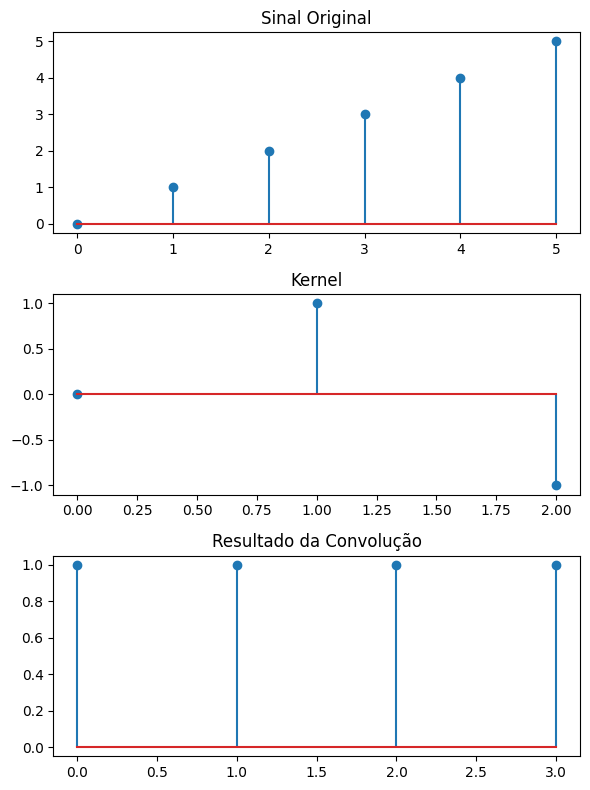

In [17]:
sinal = np.array([0, 1, 2, 3, 4, 5])
kernel = np.array([0, 1, -1])

result = np.convolve(sinal, kernel, mode='valid')
print(f"Sinal: {sinal}")
print(f"Kenel: {kernel}")
print(f"Resultado da convolução: {result}")

fig, ax = plt.subplots(3, 1, figsize=(6, 8))
#figura 1: Sinal Original
ax[0].stem(sinal, markerfmt='o')
ax[0].set_title('Sinal Original')

#figura 2: Kernel
ax[1].stem(kernel, markerfmt='o')
ax[1].set_title('Kernel')

#figura 3: Resultado da Convolução
ax[2].stem(result, markerfmt='o')
ax[2].set_title('Resultado da Convolução')

plt.tight_layout()
plt.show()

Convolução 2d usando Convolução Separável

Saving Hanni AKA amor da minha vida.jpg to Hanni AKA amor da minha vida (8).jpg


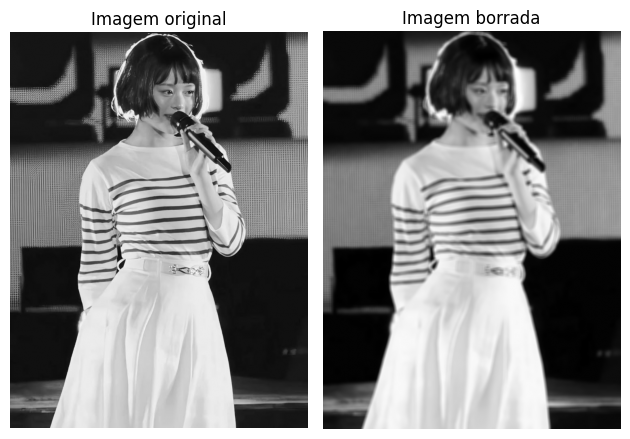

In [18]:
name, image_matriz = upload_image()
kernel_size = 9
kernel = np.ones(kernel_size) / kernel_size
image_burred = convolution1d(image_matriz, kernel)
image_burred = convolution1d(image_burred.T, kernel).T

fig, axs = plt.subplots(1, 2)

axs[0].imshow(image_matriz, cmap="gray")
axs[0].set_title("Imagem original")
axs[0].axis("off")

axs[1].imshow(image_burred, cmap="gray")
axs[1].set_title("Imagem borrada")
axs[1].axis("off")

plt.tight_layout()
plt.show()


CONVOLUÇÃO 2D COM USNADO A BIBLIOTECA SCIPY

Saving Hanni AKA amor da minha vida.jpg to Hanni AKA amor da minha vida (10).jpg


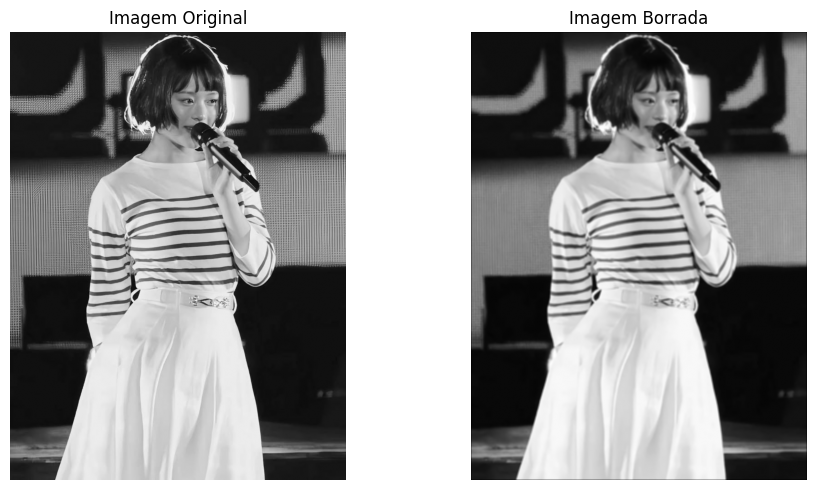

In [20]:
image_gray = upload_image()[1]
kernel_blur = np.ones((5, 5)) / 25
image_blurred = signal.convolve2d(image_gray, kernel_blur, mode='same')

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(image_gray, cmap='gray')
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(image_blurred, cmap='gray')
axs[1].set_title('Imagem Borrada')
axs[1].axis('off')

plt.tight_layout()
plt.show()